## Libararies

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    precision_recall_curve,
    auc,
)

## Load Dataset

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("wordsforthewise/lending-club")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\Lenovo\.cache\kagglehub\datasets\wordsforthewise\lending-club\versions\3


In [3]:
# Use correct file path and filename
filepath = os.path.join(path, "accepted_2007_to_2018Q4.csv.gz")

df = pd.read_csv(filepath, low_memory=False)
df.head()

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
0,68407277,NaN,3600.0,3600.0,3600.0,36 months,13.99,123.03,C,C4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
1,68355089,NaN,24700.0,24700.0,24700.0,36 months,11.99,820.28,C,C1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
2,68341763,NaN,20000.0,20000.0,20000.0,60 months,10.78,432.66,B,B4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
3,66310712,NaN,35000.0,35000.0,35000.0,60 months,14.85,829.90,C,C5,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
4,68476807,NaN,10400.0,10400.0,10400.0,60 months,22.45,289.91,F,F1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN


## Filter out relevent columns for our research question

In [4]:
relevant_columns = [
    # Loan Characteristics
    "loan_amnt",
    "term",
    "int_rate",
    "grade",
    "purpose",
    # Borrower's Financials & History
    "annual_inc",
    "dti",
    "delinq_2yrs",
    "inq_last_6mths",
    "home_ownership",
    "emp_length",
    "fico_range_low",
    "fico_range_high",
    "issue_d",
    "earliest_cr_line",
    "open_acc",
    "pub_rec",
    "revol_bal",
    "revol_util",
    "total_acc",
    "verification_status",
    "application_type",
    # Target Variable
    "loan_status",
]
df = df[relevant_columns]
df.head()

,loan_amnt,term,int_rate,grade,purpose,annual_inc,dti,delinq_2yrs,inq_last_6mths,home_ownership,...,issue_d,earliest_cr_line,open_acc,pub_rec,revol_bal,revol_util,total_acc,verification_status,application_type,loan_status
0,3600.0,36 months,13.99,C,debt_consolidation,55000.0,5.91,0.0,1.0,MORTGAGE,...,Dec-2015,Aug-2003,7.0,0.0,2765.0,29.7,13.0,Not Verified,Individual,Fully Paid
1,24700.0,36 months,11.99,C,small_business,65000.0,16.06,1.0,4.0,MORTGAGE,...,Dec-2015,Dec-1999,22.0,0.0,21470.0,19.2,38.0,Not Verified,Individual,Fully Paid
2,20000.0,60 months,10.78,B,home_improvement,63000.0,10.78,0.0,0.0,MORTGAGE,...,Dec-2015,Aug-2000,6.0,0.0,7869.0,56.2,18.0,Not Verified,Joint App,Fully Paid
3,35000.0,60 months,14.85,C,debt_consolidation,110000.0,17.06,0.0,0.0,MORTGAGE,...,Dec-2015,Sep-2008,13.0,0.0,7802.0,11.6,17.0,Source Verified,Individual,Current
4,10400.0,60 months,22.45,F,major_purchase,104433.0,25.37,1.0,3.0,MORTGAGE,...,Dec-2015,Jun-1998,12.0,0.0,21929.0,64.5,35.0,Source Verified,Individual,Fully Paid


## Target Variables

In [5]:
df["loan_status"].value_counts()

loan_status
Fully Paid                                             1076751
Current                                                 878317
Charged Off                                             268559
Late (31-120 days)                                       21467
In Grace Period                                           8436
Late (16-30 days)                                         4349
Does not meet the credit policy. Status:Fully Paid        1988
Does not meet the credit policy. Status:Charged Off        761
Default                                                     40
Name: count, dtype: int64

**Target feature change into Binary**

In [6]:
# Create a binary target variable: 1 for default, 0 for non-default
bad_statuses = ["Charged Off", "Default"]
df["is_default"] = df["loan_status"].apply(lambda x: 1 if x in bad_statuses else 0)

# Filter for only loans with a resolved outcome
resolved_statuses = ["Fully Paid"] + bad_statuses
df_cleaned = df[df["loan_status"].isin(resolved_statuses)].copy()
df_cleaned = df_cleaned.drop("loan_status", axis=1)

print(f"Original shape: {df.shape}")
print(f"Shape after filtering for resolved loans: {df_cleaned.shape}")
df["is_default"].value_counts()

Original shape: (2260701, 24)
Shape after filtering for resolved loans: (1345350, 23)


is_default
0    1992102
1     268599
Name: count, dtype: int64

## Missing Values

In [7]:
# Function to fill missing values
def fill_missing_values(df):
    """
    Fills missing values in a DataFrame based on column data type.

    Args:
      df: The input pandas DataFrame.

    Returns:
      The DataFrame with missing values filled.
    """
    for col in df.columns:
        if df[col].isnull().any():
            if df[col].dtype in ["int64", "float64"]:
                mean_val = df[col].mean()
                df[col].fillna(mean_val, inplace=True)
            else:
                mode_val = df[col].mode()[0]
                df[col].fillna(mode_val, inplace=True)
    return df


df = fill_missing_values(df_cleaned)

print("Missing values after filling:")
print(df.isna().sum())

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_8632\1951051308.py:16: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(mean_val, inplace=True)
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_8632\1951051308.py:19: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, wh

Missing values after filling:
loan_amnt              0
term                   0
int_rate               0
grade                  0
purpose                0
annual_inc             0
dti                    0
delinq_2yrs            0
inq_last_6mths         0
home_ownership         0
emp_length             0
fico_range_low         0
fico_range_high        0
issue_d                0
earliest_cr_line       0
open_acc               0
pub_rec                0
revol_bal              0
revol_util             0
total_acc              0
verification_status    0
application_type       0
is_default             0
dtype: int64


## Date time/Category Values

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1345350 entries, 0 to 2260697
Data columns (total 23 columns):
 #   Column               Non-Null Count    Dtype  
---  ------               --------------    -----  
 0   loan_amnt            1345350 non-null  float64
 1   term                 1345350 non-null  object 
 2   int_rate             1345350 non-null  float64
 3   grade                1345350 non-null  object 
 4   purpose              1345350 non-null  object 
 5   annual_inc           1345350 non-null  float64
 6   dti                  1345350 non-null  float64
 7   delinq_2yrs          1345350 non-null  float64
 8   inq_last_6mths       1345350 non-null  float64
 9   home_ownership       1345350 non-null  object 
 10  emp_length           1345350 non-null  object 
 11  fico_range_low       1345350 non-null  float64
 12  fico_range_high      1345350 non-null  float64
 13  issue_d              1345350 non-null  object 
 14  earliest_cr_line     1345350 non-null  object 
 15  ope

In [9]:
df.select_dtypes(include=["object"]).head()

,term,grade,purpose,home_ownership,emp_length,issue_d,earliest_cr_line,verification_status,application_type
0,36 months,C,debt_consolidation,MORTGAGE,10+ years,Dec-2015,Aug-2003,Not Verified,Individual
1,36 months,C,small_business,MORTGAGE,10+ years,Dec-2015,Dec-1999,Not Verified,Individual
2,60 months,B,home_improvement,MORTGAGE,10+ years,Dec-2015,Aug-2000,Not Verified,Joint App
4,60 months,F,major_purchase,MORTGAGE,3 years,Dec-2015,Jun-1998,Source Verified,Individual
5,36 months,C,debt_consolidation,RENT,4 years,Dec-2015,Oct-1987,Source Verified,Individual


**Convert dates to date-time type**

In [10]:
# Engineer credit history length
# Check if the original date columns exist
if "issue_d" in df.columns and "earliest_cr_line" in df.columns:
    print("Engineering 'credit_history_length'...")
    # Ensure columns are datetime before performing operations
    df["issue_d"] = pd.to_datetime(df["issue_d"])
    df["earliest_cr_line"] = pd.to_datetime(df["earliest_cr_line"])
    df["credit_history_length"] = (
        (df["issue_d"] - df["earliest_cr_line"]).dt.days / 30
    ).round(0)
    # Drop original date columns now that we're done with them
    df = df.drop(columns=["issue_d", "earliest_cr_line"], errors="ignore")

df["credit_history_length"].head()

Engineering 'credit_history_length'...


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_8632\4159934486.py:6: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["issue_d"] = pd.to_datetime(df["issue_d"])
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_8632\4159934486.py:7: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["earliest_cr_line"] = pd.to_datetime(df["earliest_cr_line"])


0    150.0
1    195.0
2    187.0
4    213.0
5    343.0
Name: credit_history_length, dtype: float64

**Strip leading/tailing white spaces**

In [11]:
df = df.apply(lambda col: col.str.strip() if col.dtypes == "object" else col)

In [12]:
df["term"] = df["term"].str.strip().str.replace(" months", "").astype(int)

In [13]:
def clean_emp_length(val):
    val = str(val).lower()  # convert everything to lowercase string
    if "< 1" in val:
        return 0
    elif "10+" in val:
        return 10
    elif "n/a" in val:
        return -1
    else:
        num = "".join([c for c in val if c.isdigit()])
        return int(num) if num else -1


# Apply the function
df["emp_length"] = df["emp_length"].apply(clean_emp_length).astype(int)

In [14]:
# In home_ownership column, 'ANY,OTHER and NONE' do not make sense to be alone
# themselves so that will group into 'OTHER'
home_ownership_mapping = {
    "ANY": "other",
    "MORTGAGE": "mortgage",
    "RENT": "rent",
    "OWN": "own",
    "NONE": "other",
}
df.home_ownership = df.home_ownership.map(home_ownership_mapping)

In [15]:
# Step 1: Get top 5 most frequent purposes
top_purposes = df["purpose"].value_counts().nlargest(5).index.tolist()

# Step 2: Replace rare ones with "other"
df["purpose"] = df["purpose"].apply(lambda x: x if x in top_purposes else "other")

# Step 3: One-hot encode with clear column names
purpose_dummies = pd.get_dummies(df["purpose"], prefix="purpose").astype(int)

# Example of how column names will look:
# purpose_debt_consolidation, purpose_small_business, purpose_home_improvement, etc.

# Step 4: Drop original and concat new columns
df = df.drop("purpose", axis=1)
df = pd.concat([df, purpose_dummies], axis=1)
# Step 5: Clean up column names
df.columns = df.columns.str.replace("purpose_", "purpose_", regex=False)

In [16]:
# Engineer a single FICO score
# Check if the original FICO columns still exist before trying to create the new one
if "fico_range_low" in df.columns and "fico_range_high" in df.columns:
    print("Engineering 'fico_score'...")
    df["fico_score"] = (df["fico_range_low"] + df["fico_range_high"]) / 2
    df = df.drop(columns=["fico_range_low", "fico_range_high"])

print(df["fico_score"].dtypes)
df["fico_score"].head()

Engineering 'fico_score'...
float64


0    677.0
1    717.0
2    697.0
4    697.0
5    692.0
Name: fico_score, dtype: float64

In [17]:
def value_counter(df):
    for col in df.select_dtypes(["object"]).columns:
        print(df[col].value_counts(dropna=False))


value_counter(df)

grade
B    392748
C    381694
A    235095
D    200966
E     93656
F     32059
G      9132
Name: count, dtype: int64
home_ownership
mortgage    665596
rent        534436
own         144840
other          334
NaN            144
Name: count, dtype: int64
verification_status
Source Verified    521289
Verified           418352
Not Verified       405709
Name: count, dtype: int64
application_type
Individual    1319544
Joint App       25806
Name: count, dtype: int64


## All to Numeric Features

In [18]:
cat_cols = df.select_dtypes(include=["object"]).columns
num_cols = df.select_dtypes(exclude=["object"]).drop("is_default", axis=1).columns

# Concatenate numeric columns explicitly
df_final = pd.concat(
    [df[num_cols], pd.get_dummies(df[cat_cols], drop_first=True), df["is_default"]],
    axis=1,
)
df_final.head()

,loan_amnt,term,int_rate,annual_inc,dti,delinq_2yrs,inq_last_6mths,emp_length,open_acc,pub_rec,...,grade_E,grade_F,grade_G,home_ownership_other,home_ownership_own,home_ownership_rent,verification_status_Source Verified,verification_status_Verified,application_type_Joint App,is_default
0,3600.0,36,13.99,55000.0,5.91,0.0,1.0,10,7.0,0.0,...,False,False,False,False,False,False,False,False,False,0
1,24700.0,36,11.99,65000.0,16.06,1.0,4.0,10,22.0,0.0,...,False,False,False,False,False,False,False,False,False,0
2,20000.0,60,10.78,63000.0,10.78,0.0,0.0,10,6.0,0.0,...,False,False,False,False,False,False,False,False,True,0
4,10400.0,60,22.45,104433.0,25.37,1.0,3.0,3,12.0,0.0,...,False,True,False,False,False,False,True,False,False,0
5,11950.0,36,13.44,34000.0,10.20,0.0,0.0,4,5.0,0.0,...,False,False,False,False,False,True,True,False,False,0


## Preporcessing

In [19]:
# Preprocess Data
X = df_final.drop("is_default", axis=1)
y = df_final["is_default"]

# Scale numeric features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

## Training (Using Class Weights)

In [20]:
# Initialize models
logreg = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)

rf = RandomForestClassifier(n_estimators=100, class_weight="balanced", random_state=42)

pos_weight = df["is_default"].value_counts()[0] / df["is_default"].value_counts()[1]
xgb = XGBClassifier(
    use_label_encoder=False,
    eval_metric="logloss",
    scale_pos_weight=pos_weight,
    random_state=42,
)

In [21]:
# Logistic Regression
logreg.fit(X_train, y_train)
y_pred_log = logreg.predict(X_test)
y_proba_log = logreg.predict_proba(X_test)[:, 1]  # Probabilities

# Random Forest
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]  # Probabilities

# XGBoost
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)
y_proba_xgb = xgb.predict_proba(X_test)[:, 1]  # Probabilities

C:\Users\Lenovo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\xgboost\training.py:183: UserWarning: [23:04:45] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


## Evaluation

In [22]:
# Evaluation function
def evaluate_model(y_test, y_pred, y_proba, model_name):
    print(f"\n=== {model_name} ===")
    print(classification_report(y_test, y_pred))
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
    print("ROC-AUC:", roc_auc_score(y_test, y_proba))


# Evaluate all models
evaluate_model(y_test, y_pred_log, y_proba_log, "Logistic Regression")
evaluate_model(y_test, y_pred_rf, y_proba_rf, "Random Forest")
evaluate_model(y_test, y_pred_xgb, y_proba_xgb, "XGBoost")


=== Logistic Regression ===
              precision    recall  f1-score   support

           0       0.88      0.63      0.74    215385
           1       0.31      0.67      0.43     53685

    accuracy                           0.64    269070
   macro avg       0.60      0.65      0.58    269070
weighted avg       0.77      0.64      0.67    269070

Confusion Matrix:
 [[136101  79284]
 [ 17758  35927]]
ROC-AUC: 0.7078234432901731

=== Random Forest ===
              precision    recall  f1-score   support

           0       0.81      0.99      0.89    215385
           1       0.54      0.05      0.10     53685

    accuracy                           0.80    269070
   macro avg       0.68      0.52      0.49    269070
weighted avg       0.76      0.80      0.73    269070

Confusion Matrix:
 [[212947   2438]
 [ 50768   2917]]
ROC-AUC: 0.7029496408796194

=== XGBoost ===
              precision    recall  f1-score   support

           0       0.89      0.65      0.75    215385
    

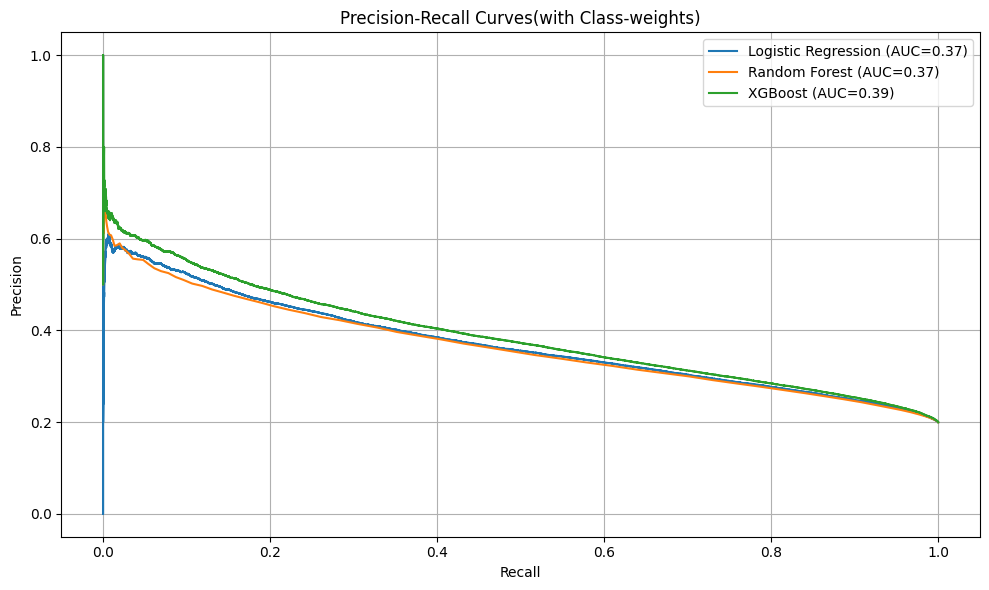

In [23]:
# Plot Precision-Recall Curves
plt.figure(figsize=(10, 6))
for y_proba, name in zip(
    [y_proba_log, y_proba_rf, y_proba_xgb],
    ["Logistic Regression", "Random Forest", "XGBoost"],
):
    precision, recall, thresholds = precision_recall_curve(y_test, y_proba)
    pr_auc = auc(recall, precision)
    plt.plot(recall, precision, label=f"{name} (AUC={pr_auc:.2f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curves(with Class-weights)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

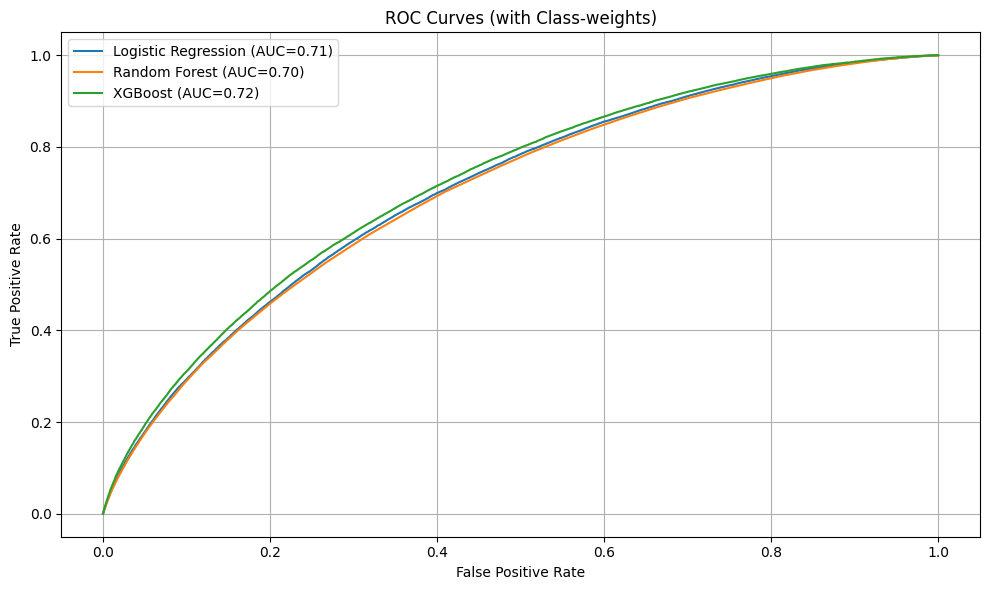

In [24]:
# Roc-AUC Curves
from sklearn.metrics import roc_curve

plt.figure(figsize=(10, 6))
for y_proba, name in zip(
    [y_proba_log, y_proba_rf, y_proba_xgb],
    ["Logistic Regression", "Random Forest", "XGBoost"],
):
    roc_auc = roc_auc_score(y_test, y_proba)
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC={roc_auc:.2f})")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves (with Class-weights)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## Hyperparameter Tuning 

### Using SHAP

In [25]:
# import shap

# explainer = shap.Explainer(xgb, X_train)
# shap_values = explainer(X_test)

# shap.summary_plot(shap_values, X_test, plot_type="bar")

In [26]:
# def select_shap_features(X, shap_indices, return_dropped=False, verbose=True):
#     """
#     Filters a DataFrame to retain only SHAP-important features based on index positions.

#     Parameters:
#         X (pd.DataFrame): Original feature DataFrame.
#         shap_indices (list): SHAP-ordered feature indices (e.g., from explainer).
#         return_dropped (bool): Whether to return dropped feature names. Default: False.
#         verbose (bool): If True, prints out selected and dropped features.

#     Returns:
#         X_selected (pd.DataFrame): DataFrame with selected features only.
#         selected_features (list): List of selected feature names.
#         dropped_features (list, optional): List of dropped feature names (if return_dropped=True).
#     """
#     # Error checks
#     if not isinstance(X, pd.DataFrame):
#         raise ValueError("Input X must be a pandas DataFrame.")

#     if not shap_indices:
#         raise ValueError("shap_indices list is empty.")

#     if any(i >= len(X.columns) or i < 0 for i in shap_indices):
#         raise IndexError("One or more indices in shap_indices are out of bounds.")

#     feature_names = X.columns.tolist()
#     selected_features = [feature_names[i] for i in shap_indices]
#     dropped_features = list(set(feature_names) - set(selected_features))

#     X_selected = X[selected_features]

#     if verbose:
#         print("✅ Selected Features:")
#         print(selected_features)
#         print(f"\n🚫 Dropped {len(dropped_features)} feature(s):")
#         print(dropped_features)

#     if return_dropped:
#         return X_selected, selected_features, dropped_features
#     return X_selected, selected_features


# # Assume X is your input DataFrame of features
# shap_indices = [1, 20, 0, 29, 2, 7, 9, 3, 13, 11, 5, 21, 12, 30, 6, 14, 31, 22, 19, 28]

# # Call the function
# X_selected, selected_names, dropped_names = select_shap_features(
#     X, shap_indices, return_dropped=True, verbose=True
# )

# print(X_selected.shape)

In [27]:
# # train/test split with SHAP-selected features
# X_train_shap, X_test_shap, y_train, y_test = train_test_split(
#     X_selected, y, test_size=0.2, random_state=42
# )

# # Refit XGBoost with reduced features
# xgb.fit(X_train_shap, y_train)
# y_pred_xgb_shap = xgb.predict(X_test_shap)
# y_proba_xgb_shap = xgb.predict_proba(X_test_shap)[:, 1]  # Probabilities
# print(classification_report(y_test, y_pred_xgb_shap))
# print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_xgb_shap))
# print("ROC-AUC:", roc_auc_score(y_test, xgb.predict_proba(X_test_shap)[:, 1]))

### Using RandomizedSearchCV

In [28]:
from sklearn.model_selection import RandomizedSearchCV

# Compute ratio
scale_pos_weight = len(y_train[y_train == 0]) / len(y_train[y_train == 1])

# Include in hyperparameter search
param_grid = {
    "max_depth": [3, 5, 7],
    "learning_rate": [0.05, 0.1, 0.2],
    "n_estimators": [100, 200],
    "subsample": [0.8, 1],
    "colsample_bytree": [0.8, 1],
    "gamma": [0, 0.2, 0.5],
    "scale_pos_weight": [scale_pos_weight],  # NEW
}

search = RandomizedSearchCV(
    xgb,
    param_distributions=param_grid,
    n_iter=10,
    scoring="recall",
    cv=3,
    verbose=1,
    n_jobs=-1,
)
search.fit(X_train, y_train)
print("Best parameters:", search.best_params_)

Fitting 3 folds for each of 10 candidates, totalling 30 fits


C:\Users\Lenovo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\xgboost\training.py:183: UserWarning: [23:07:43] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Best parameters: {'subsample': 0.8, 'scale_pos_weight': 4.0079566710405095, 'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.1, 'gamma': 0.2, 'colsample_bytree': 0.8}


In [33]:
best_params = {
    "subsample": 0.8,
    "scale_pos_weight": 4.0079566710405095,
    "n_estimators": 200,
    "max_depth": 3,
    "learning_rate": 0.1,
    "gamma": 0.2,
    "colsample_bytree": 0.8,
}

# Initialize model with best parameters
final_model = XGBClassifier(
    **best_params,
    use_label_encoder=False,
    eval_metric="logloss",  # suppresses warning
    random_state=42,
)

# Train on the full training set
final_model.fit(X_train, y_train)

C:\Users\Lenovo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\xgboost\training.py:183: UserWarning: [23:24:44] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=0.2,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=3, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, ...)

In [34]:
# Predict
y_pred = final_model.predict(X_test)
y_prob = final_model.predict_proba(X_test)[:, 1]

# Evaluate
print("=== Final XGBoost Performance ===")
print(classification_report(y_test, y_pred))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob):.4f}")

=== Final XGBoost Performance ===
              precision    recall  f1-score   support

           0       0.89      0.64      0.74    215385
           1       0.32      0.67      0.43     53685

    accuracy                           0.65    269070
   macro avg       0.60      0.66      0.59    269070
weighted avg       0.77      0.65      0.68    269070

Confusion Matrix:
[[138131  77254]
 [ 17611  36074]]
ROC-AUC: 0.7163


## Feature Importance

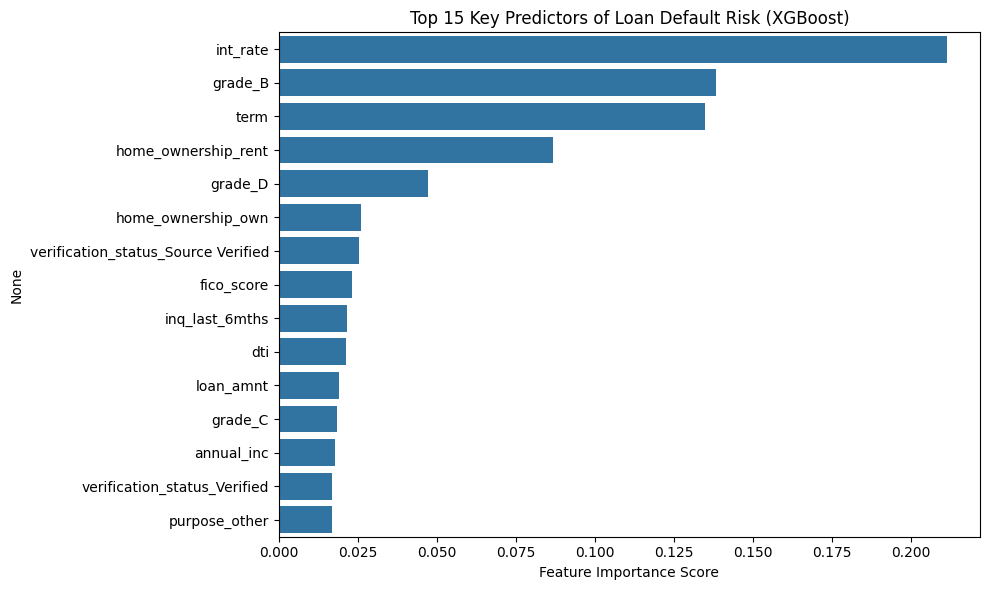

In [35]:
# XGBoost
xgb_importances = pd.Series(xgb.feature_importances_, index=X.columns).sort_values(
    ascending=False
)

# Plot Top 15 Features
plt.figure(figsize=(10, 6))
sns.barplot(x=xgb_importances[:15], y=xgb_importances.index[:15])
plt.title("Top 15 Key Predictors of Loan Default Risk (XGBoost)")
plt.xlabel("Feature Importance Score")
plt.tight_layout()
plt.show()

## Save Models

In [36]:
# Save XGBoost model
import joblib

joblib.dump(xgb, "xgb_model.pkl")

['xgb_model.pkl']